# Laboratorio 5 — Agentes en el Arcade Learning Environment (ALE): Space Invaders
## Modulo de desarrollo: funciones para interactuar con ALE

Este notebook contiene unicamente el codigo y el procedimiento del modulo de desarrollo
(seccion 3 de las instrucciones): construccion del modulo `scripts/ale_utils.py`
(`crear_entorno`, `agente_aleatorio`, `agente_regla_simple`, `ejecutar_episodio`,
`generar_video_agente`), su prueba sobre `ALE/SpaceInvaders-v5`, y la generacion de los
videos entregables. La investigacion teorica sobre ALE (secciones 1 y 2 del enunciado) se
presenta en el reporte PDF adjunto (`docs/reporte.pdf`).

### 1. Entorno de ejecucion y modulo `ale_utils`

El entorno de este proyecto (Python, Jupyter, `gymnasium`, `ale-py`, `moviepy`, etc.) se
define en `flake.nix` y se activa con `nix develop` (o automaticamente via `direnv`); no se
instalan paquetes por separado dentro del notebook.

Los binarios de ROM de Atari (licenciados para investigacion/uso libre por Farama desde
ALE 0.8.0) no vienen incluidos en el paquete `ale-py` de nixpkgs por razones de empaquetado,
asi que se distribuyen aparte en `assets/roms/space_invaders.bin` (descargados oficialmente
desde el paquete `ale-py` de PyPI y verificados con el hash MD5 esperado por ALE). El modulo
`scripts/ale_utils.py` fija la variable de entorno `ALE_ROMS_DIR` para que `ale-py` los
encuentre automaticamente, sin importar el directorio de trabajo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "scripts"))

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video

import ale_utils as au

print("gymnasium version:", gym.__version__)
import ale_py
print("ale-py version:", ale_py.__version__)

gymnasium version: 1.2.2
ale-py version: 0.11.2


### 2. Entorno `ALE/SpaceInvaders-v5`: espacios de observacion y accion

Se crea el entorno con `crear_entorno` (sin `video_folder`, es decir sin grabacion) y se
inspeccionan `observation_space` y `action_space`, igual que se hizo con `CartPole-v1` en el
laboratorio anterior.

In [2]:
env = au.crear_entorno("ALE/SpaceInvaders-v5")

print("Observation space:", env.observation_space)
print("  tipo:", type(env.observation_space).__name__)
print("  shape:", env.observation_space.shape)
print("  dtype:", env.observation_space.dtype)

print("Action space:", env.action_space)
print("  tipo:", type(env.action_space).__name__)
print("  n:", env.action_space.n)
print("  significado de cada accion:", env.unwrapped.get_action_meanings())

env.close()

Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Observation space: Box(0, 255, (210, 160, 3), uint8)
  tipo: Box
  shape: (210, 160, 3)
  dtype: uint8
Action space: Discrete(6)
  tipo: Discrete
  n: 6
  significado de cada accion: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


A.L.E: Arcade Learning Environment (version 0.11.2+unknown)
[Powered by Stella]


### 3. Agente aleatorio (baseline) — 5 episodios sin grabacion

Se usa `agente_aleatorio` (retorna `env.action_space.sample()`) junto con `ejecutar_episodio`
para correr 5 episodios completos y registrar pasos sobrevividos y recompensa total (return)
de cada uno.

In [3]:
random_steps, random_returns = [], []

for ep in range(5):
    env = au.crear_entorno("ALE/SpaceInvaders-v5")
    env.reset(seed=ep)
    steps, total_reward = au.ejecutar_episodio(env, au.agente_aleatorio)
    env.close()
    random_steps.append(steps)
    random_returns.append(total_reward)
    print(f"[agente_aleatorio] episodio {ep + 1}: steps={steps}, return={total_reward:.1f}")

print(f"\nPromedio: steps={np.mean(random_steps):.1f}, return={np.mean(random_returns):.1f}")

Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_aleatorio] episodio 1: steps=514, return=120.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_aleatorio] episodio 2: steps=609, return=200.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_aleatorio] episodio 3: steps=299, return=120.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_aleatorio] episodio 4: steps=1222, return=635.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_aleatorio] episodio 5: steps=384, return=45.0

Promedio: steps=605.6, return=224.0


### 4. Agente de regla simple — 5 episodios sin grabacion

`agente_regla_simple` alterna bloques de 10 pasos moviendose y disparando hacia la derecha
(`RIGHTFIRE`) y hacia la izquierda (`LEFTFIRE`), sin necesidad de entrenamiento. Se compara su
desempeno contra el agente aleatorio bajo el mismo procedimiento de 5 episodios.

In [4]:
simple_steps, simple_returns = [], []

for ep in range(5):
    env = au.crear_entorno("ALE/SpaceInvaders-v5")
    env.reset(seed=ep)
    steps, total_reward = au.ejecutar_episodio(env, au.agente_regla_simple)
    env.close()
    simple_steps.append(steps)
    simple_returns.append(total_reward)
    print(f"[agente_regla_simple] episodio {ep + 1}: steps={steps}, return={total_reward:.1f}")

print(f"\nPromedio: steps={np.mean(simple_steps):.1f}, return={np.mean(simple_returns):.1f}")

Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_regla_simple] episodio 1: steps=290, return=90.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_regla_simple] episodio 2: steps=377, return=100.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_regla_simple] episodio 3: steps=541, return=105.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_regla_simple] episodio 4: steps=397, return=60.0
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...
Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


[agente_regla_simple] episodio 5: steps=266, return=20.0

Promedio: steps=374.2, return=75.0


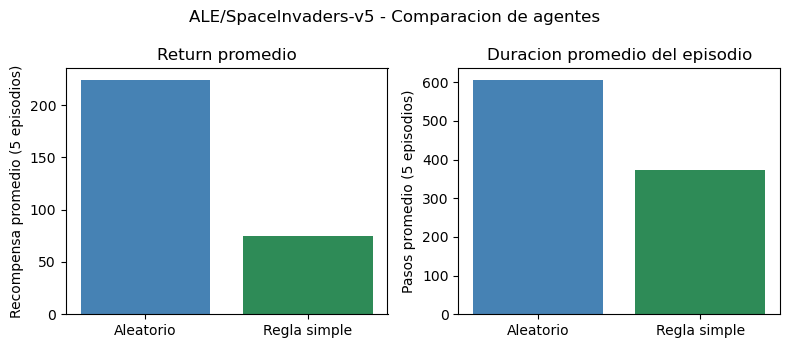

In [5]:
labels = ["Aleatorio", "Regla simple"]
avg_returns = [np.mean(random_returns), np.mean(simple_returns)]
avg_steps = [np.mean(random_steps), np.mean(simple_steps)]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

axes[0].bar(labels, avg_returns, color=["steelblue", "seagreen"])
axes[0].set_ylabel("Recompensa promedio (5 episodios)")
axes[0].set_title("Return promedio")

axes[1].bar(labels, avg_steps, color=["steelblue", "seagreen"])
axes[1].set_ylabel("Pasos promedio (5 episodios)")
axes[1].set_title("Duracion promedio del episodio")

fig.suptitle("ALE/SpaceInvaders-v5 - Comparacion de agentes")
fig.tight_layout()
fig.savefig("../docs/fig_spaceinvaders_comparison.png", dpi=150)
plt.show()

### 5. Generacion de video: agente aleatorio jugando `ALE/SpaceInvaders-v5` (entregable)

`generar_video_agente` combina `crear_entorno` + `ejecutar_episodio`, graba el episodio con
`gymnasium.wrappers.RecordVideo`, cierra el entorno (`env.close()`, indispensable para que el
`.mp4` se escriba a disco) y retorna las rutas de video junto con las metricas de cada
episodio. Se genera 1 episodio completo, guardado en `entregables/videos/`.

In [6]:
video_paths_random, metrics_random = au.generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=au.agente_aleatorio,
    video_folder="../entregables/videos",
    name_prefix="space-invaders-aleatorio",
    n_episodios=1,
)

for video_path, metrica in zip(video_paths_random, metrics_random):
    print(f"Video: {video_path}")
    print(f"  episodio {metrica['episodio']}: steps={metrica['steps']}, return={metrica['return']:.1f}")

Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


/nix/store/vwr5s7nzmcsiynklll82lyrxc7qhbn9l-python3-3.13.12-env/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/entregables/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video: ../entregables/videos/space-invaders-aleatorio-episode-0.mp4
  episodio 0: steps=373, return=105.0


In [7]:
Video(video_paths_random[0], embed=True, width=320)

### 6. Video adicional: agente de regla simple (comparacion)

No es un entregable obligatorio (el enunciado pide al menos 1 video del agente aleatorio),
pero se genera tambien un video del `agente_regla_simple` con la misma funcion de alto nivel,
para poder comparar visualmente su comportamiento contra el del agente aleatorio.

In [8]:
video_paths_simple, metrics_simple = au.generar_video_agente(
    nombre_entorno="ALE/SpaceInvaders-v5",
    funcion_agente=au.agente_regla_simple,
    video_folder="../entregables/videos",
    name_prefix="space-invaders-regla-simple",
    n_episodios=1,
)

for video_path, metrica in zip(video_paths_simple, metrics_simple):
    print(f"Video: {video_path}")
    print(f"  episodio {metrica['episodio']}: steps={metrica['steps']}, return={metrica['return']:.1f}")

Loading roms from /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/assets/roms...


/nix/store/vwr5s7nzmcsiynklll82lyrxc7qhbn9l-python3-3.13.12-env/lib/python3.13/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/pedro0210/Documents/Uvg/FourthYear/Deep-Learning/Lab-05/entregables/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Video: ../entregables/videos/space-invaders-regla-simple-episode-0.mp4
  episodio 0: steps=480, return=155.0


In [9]:
Video(video_paths_simple[0], embed=True, width=320)

### 7. Resumen de metricas de los videos generados

| Video | Agente | Pasos sobrevividos | Recompensa total (return) |
|---|---|---|---|
| `space-invaders-aleatorio-episode-0.mp4` | `agente_aleatorio` | 373 | 105.0 |
| `space-invaders-regla-simple-episode-0.mp4` | `agente_regla_simple` | 480 | 155.0 |

Ambos videos quedan guardados en `entregables/videos/` junto con este notebook y son el
entregable `.mp4` solicitado en el enunciado (agente aleatorio en `ALE/SpaceInvaders-v5`).